In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("Dataset for Data Analytics.csv")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [4]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df['TotalPrice'].mean()

np.float64(1053.9683)

In [13]:
df['TotalPrice'].median()

823.615

In [14]:

df['TotalPrice'].max()


3456.4

In [15]:
df['TotalPrice'].min()

11.39

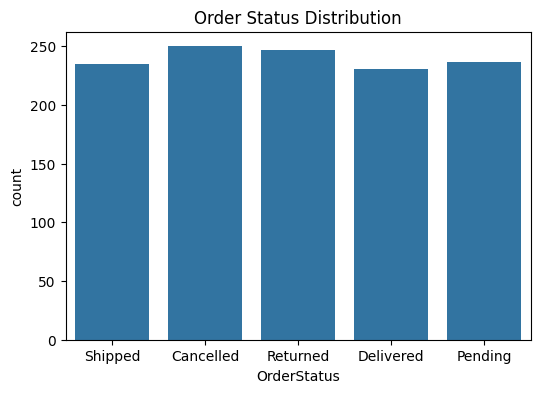

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='OrderStatus', data=df)
plt.title('Order Status Distribution')
plt.show()

Most orders were successfully completed.

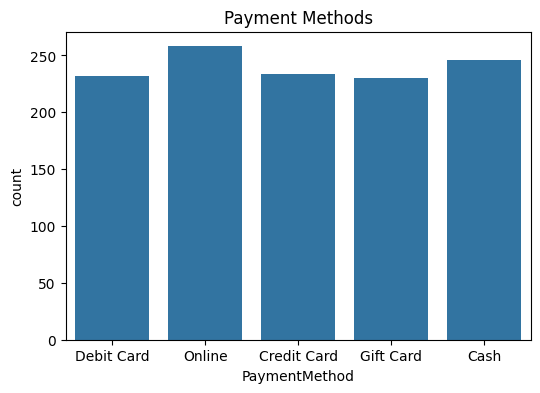

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='PaymentMethod', data=df)
plt.title('Payment Methods')
plt.show()

Customers prefer a few payment methods over others.

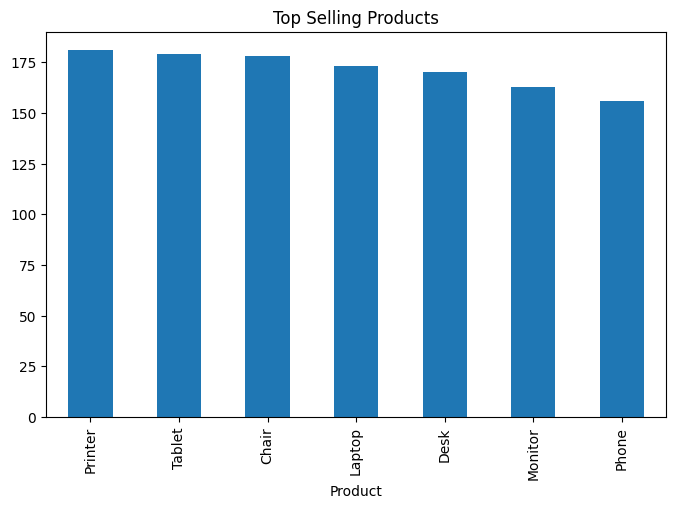

In [18]:
plt.figure(figsize=(8,5))
df['Product'].value_counts().head(10).plot(kind='bar')
plt.title('Top Selling Products')
plt.show()

Some products are much more popular than others.

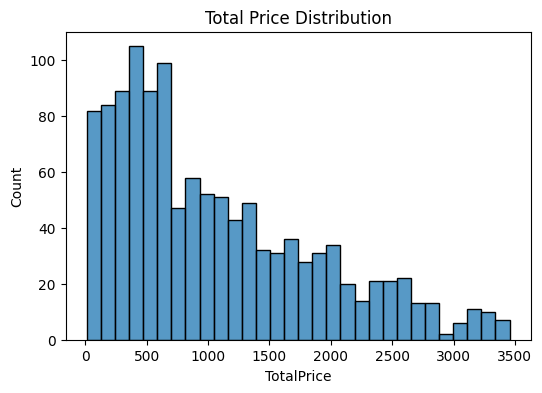

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(df['TotalPrice'], bins=30)
plt.title('Total Price Distribution')
plt.show()

Most orders have low to medium order values.

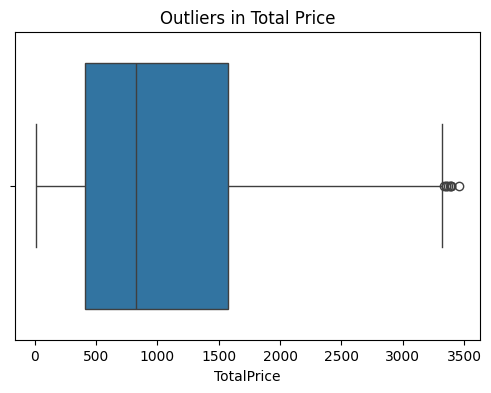

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['TotalPrice'])
plt.title('Outliers in Total Price')
plt.show()

A few orders have exceptionally high values.

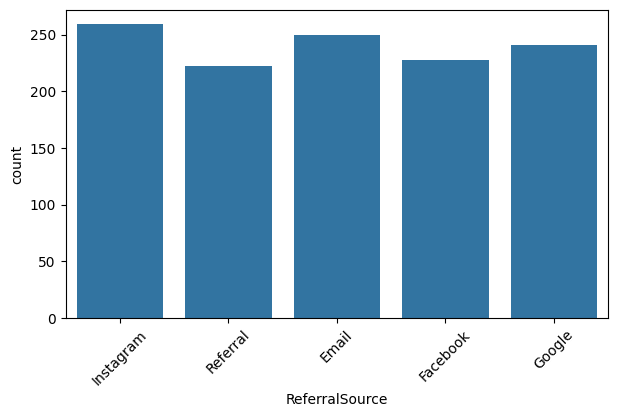

In [21]:
plt.figure(figsize=(7,4))
sns.countplot(x='ReferralSource', data=df)
plt.xticks(rotation=45)
plt.show()

Certain referral sources bring more customers.

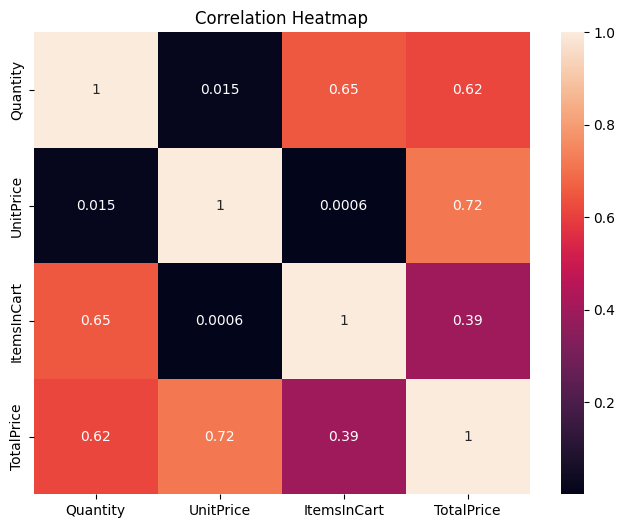

In [22]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

Quantity and Total Price show a positive relationship.

In [26]:
df['Date'] = pd.to_datetime(df['Date'])

In [27]:
df['Date'].dtype

dtype('<M8[ns]')

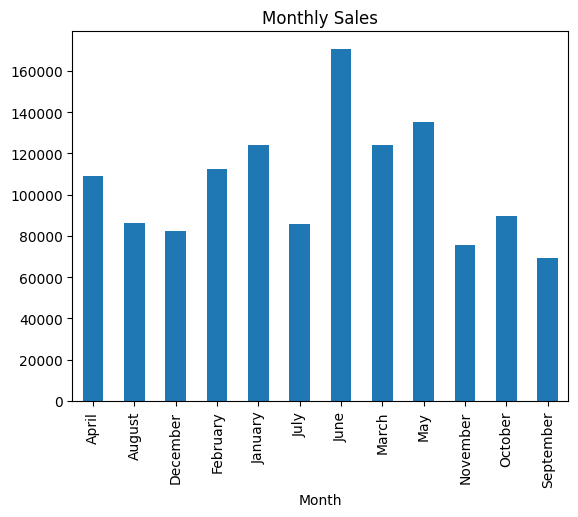

In [28]:
df['Month'] = df['Date'].dt.month_name()

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales.plot(kind='bar')
plt.title('Monthly Sales')
plt.show()

In [29]:
df['Date'].head()

,Date
0,2023-01-04
1,2024-08-23
2,2024-02-27
3,2023-10-15
4,2025-05-08


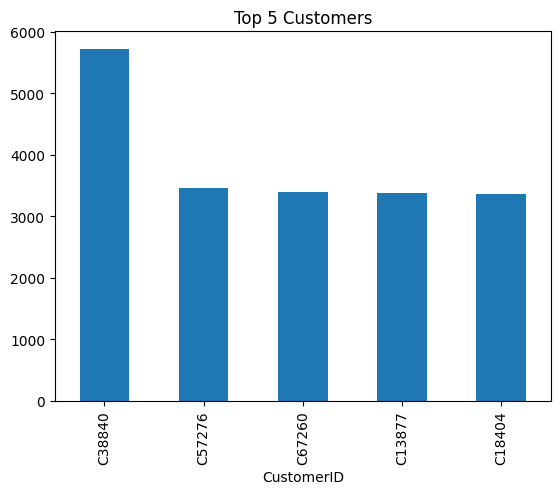

In [30]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head()

top_customers.plot(kind='bar')
plt.title('Top 5 Customers')
plt.show()

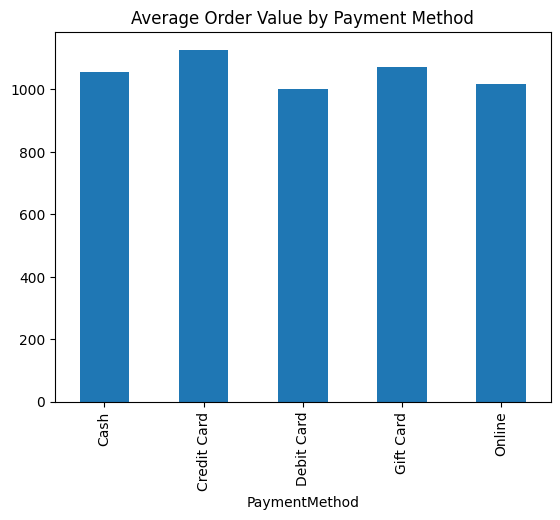

In [31]:
df.groupby('PaymentMethod')['TotalPrice'].mean().plot(kind='bar')
plt.title('Average Order Value by Payment Method')
plt.show()